# CS221 Homework 2: Sentiment Analysis

This notebook works through all four problems of the sentiment analysis homework.

- **Problem 1** (Written): Bag-of-Words & Linear Classification Intuition
- **Problem 2** (Written): Embeddings & Multilayer Perceptron Intuition
- **Problem 3** (Code): Linear Classifier Implementation
- **Problem 4** (Code): MLP with Embeddings Implementation

Key concepts from Lecture 3 (Linear Classification) and Lecture 4 (Deep Learning) are applied throughout.

In [32]:
import numpy as np
import torch
import torch.nn as nn
from einops import reduce, rearrange
import random

---
## Problem 1: Bag-of-Words & Linear Classification Intuition

### Dataset

| Tweet | Emotion | One-hot encoding |
|-------|---------|------------------|
| "amazing day" | Joy | [1,0,0] |
| "scared of spiders" | Fear | [0,0,1] |
| "love this" | Joy | [1,0,0] |
| "so angry" | Anger | [0,1,0] |
| "so so worried about tomorrow" | Fear | [0,0,1] |
| "hate waiting" | Anger | [0,1,0] |

### Vocabulary (alphabetical)

| Index | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 |
|-------|---|---|---|---|---|---|---|---|---|---|----|----|-------|--------|
| Word | about | amazing | angry | day | hate | love | of | scared | so | spiders | this | tomorrow | waiting | worried |

### 1a. Bag-of-Words Feature Vector

**Task:** Write the bag-of-words feature vector for "so so worried about tomorrow".

**From Lecture 3:** A bag-of-words representation counts (or marks) which words from the vocabulary appear in the text. It produces a fixed-size vector of length |vocabulary|, where each entry corresponds to a word.

The text "so so worried about tomorrow" contains:
- "so" appears **2 times** (index 8)
- "worried" appears **1 time** (index 13)
- "about" appears **1 time** (index 0)
- "tomorrow" appears **1 time** (index 11)

In [65]:
# Vocabulary in alphabetical order
vocabulary = ["about", "amazing", "angry", "day", "hate", "love", "of", "scared", "so", "spiders", "this", "tomorrow", "waiting", "worried"]
vocab_to_index = {word: i for i, word in enumerate(vocabulary)}

def bag_of_words(text, vocab_to_index):
    """Compute the bag-of-words feature vector (word counts)."""
    vec = np.zeros(len(vocab_to_index))
    for word in text.split():
        if word in vocab_to_index:
            vec[vocab_to_index[word]] += 1
    return vec

f_x = bag_of_words("so so worried about tomorrow", vocab_to_index)
print("Feature vector f(x):")
for i, (word, count) in enumerate(zip(vocabulary, f_x)):
    if count > 0:
        print(f"  index {i} ({word}): {int(count)}")
print(f"\nFull vector: {f_x.astype(int)}")
print(f"Vector length: {len(f_x)} (= vocabulary size)")

Feature vector f(x):
  index 0 (about): 1
  index 8 (so): 2
  index 11 (tomorrow): 1
  index 13 (worried): 1

Full vector: [1 0 0 0 0 0 0 0 2 0 0 1 0 1]
Vector length: 14 (= vocabulary size)


**Answer:**

$$f(x) = [1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 1]$$

The non-zero entries are: `about`=1, `so`=2, `tomorrow`=1, `worried`=1.

Note that word order is completely lost -- this is the fundamental trade-off of bag-of-words (Lecture 3, Section 23).

### 1b. Softmax Computation

**Task:** Compute softmax probabilities for logits $z = [2.0, 1.0, -1.0]$ corresponding to [Joy, Anger, Fear].

**From Lecture 3:** Softmax converts logits into a probability distribution:

$$p_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

In [ ]:
def softmax(logits): # function for softmax taking logits variable as input
    """Compute softmax probabilities from logits."""
    exp_logits = np.exp(logits) # exponentiate logits
    return exp_logits / np.sum(exp_logits) # returns the formula above -> exp(z_i) / sum_j exp(z_j)

logits = np.array([2.0, 1.0, -1.0]) # forms numpy array of given logits
classes = ["Joy", "Anger", "Fear"] # array of class labels

# Step-by-step computation example
exp_logits = np.exp(logits) # exponentiate logits
Z = np.sum(exp_logits)  # compute denominator (sum of exponentiated logits)
probs = exp_logits / Z # compute softmax probabilities

print("Step-by-step:")
print(f"  Logits z = {logits}") # print logits
print(f"  exp(z) = [{exp_logits[0]:.4f}, {exp_logits[1]:.4f}, {exp_logits[2]:.4f}]") # print exponentiated logits
print(f"  Sum of exp(z) = {Z:.4f}") # print sum of exponentiated logits
print(f"\nSoftmax probabilities (rounded to 3 decimals):")
for cls, p in zip(classes, probs):
    print(f"  P({cls}) = {p:.3f}") # print class probabilities rounded to 3 decimals
print(f"\nSum of probabilities = {np.sum(probs):.3f} (must be 1.0)") # sum of probabilities should be 1.0

Step-by-step:
  Logits z = [ 2.  1. -1.]
  exp(z) = [7.3891, 2.7183, 0.3679]
  Sum of exp(z) = 10.4752

Softmax probabilities (rounded to 3 decimals):
  P(Joy) = 0.705
  P(Anger) = 0.259
  P(Fear) = 0.035

Sum of probabilities = 1.000 (must be 1.0)


**Answer:**

| | Joy | Anger | Fear |
|---|---|---|---|
| Logit $z_k$ | 2.0 | 1.0 | -1.0 |
| $e^{z_k}$ | 7.389 | 2.718 | 0.368 |
| $p_k$ | **0.705** | **0.259** | **0.035** |

Joy gets the highest probability because it has the largest logit. Softmax exaggerates differences (Lecture 3, Section 15) -- the exponentiation step amplifies the gap between logits.

### 1c. Cross-Entropy Loss

**Task:** Calculate cross-entropy loss for "so angry" with:
- True label: Anger, encoded as $y = [0, 1, 0]$
- Predicted probabilities: $p = [0.2, 0.7, 0.1]$

**From Lecture 3:** Cross-entropy loss:
$$\text{Loss}_{CE} = -\sum_k y_k \log p_k$$

Since $y$ is one-hot (only $y_2 = 1$), this simplifies to:
$$\text{Loss}_{CE} = -\log p_{\text{true class}} = -\log(0.7)$$

In [ ]:
y_true = np.array([0, 1, 0])  # anger one hot encoding
p_pred = np.array([0.2, 0.7, 0.1]) # predicted probabilities from softmax

# Full cross-entropy formula
loss_terms = -y_true * np.log(p_pred) # compute -y_k * log(p_k) for each class
loss = np.sum(loss_terms) # sum over classes to get total loss

print("Cross-entropy loss computation:")
print(f"  y = {y_true}")
print(f"  p = {p_pred}")
print(f"  Terms: -y_k * log(p_k) = {loss_terms}")
print(f"  Loss = -log(0.7) = {loss:.4f}")

# Show what happens as P(correct class) -> 1
print("\nAs P(Anger) approaches 1, the loss approaches 0:")
for p in [0.1, 0.3, 0.5, 0.7, 0.9, 0.99, 0.999]: # arbitrary probabilities
    print(f"  P(Anger) = {p:.3f}  =>  Loss = {-np.log(p):.4f}")

Cross-entropy loss computation:
  y = [0 1 0]
  p = [0.2 0.7 0.1]
  Terms: -y_k * log(p_k) = [-0.          0.35667494 -0.        ]
  Loss = -log(0.7) = 0.3567

As P(Anger) approaches 1, the loss approaches 0:
  P(Anger) = 0.100  =>  Loss = 2.3026
  P(Anger) = 0.300  =>  Loss = 1.2040
  P(Anger) = 0.500  =>  Loss = 0.6931
  P(Anger) = 0.700  =>  Loss = 0.3567
  P(Anger) = 0.900  =>  Loss = 0.1054
  P(Anger) = 0.990  =>  Loss = 0.0101
  P(Anger) = 0.999  =>  Loss = 0.0010


**Answer:**

$$\text{Loss}_{CE} = -\log(0.7) \approx 0.3567$$

**Behavior as $p_{\text{correct}} \to 1$:** The loss approaches 0. This makes sense because $-\log(1) = 0$. The model is rewarded for being confident about the correct class.

**Behavior as $p_{\text{correct}} \to 0$:** The loss approaches $+\infty$. This provides an extremely strong gradient signal when the model is confidently wrong -- exactly the property that makes cross-entropy useful for gradient descent (Lecture 3, Section 11-12).

### 1d. Gradient of Cross-Entropy Loss w.r.t. Logits

**Task:** Derive $\frac{\partial \text{Loss}_{CE}}{\partial z_k}$ and express it in terms of $p_k$ and $y_k$ only.

#### Derivation

We need to differentiate the loss through the softmax. The chain rule gives:

$$\frac{\partial \text{Loss}_{CE}}{\partial z_k} = \sum_j \frac{\partial \text{Loss}_{CE}}{\partial p_j} \cdot \frac{\partial p_j}{\partial z_k}$$

**Step 1:** Gradient of loss w.r.t. probabilities:

$$\frac{\partial \text{Loss}_{CE}}{\partial p_j} = -\frac{y_j}{p_j}$$

**Step 2:** Jacobian of softmax. The softmax derivative has two cases:

$$\frac{\partial p_j}{\partial z_k} = \begin{cases} p_j(1 - p_j) & \text{if } j = k \\ -p_j p_k & \text{if } j \neq k \end{cases}$$

This can be written compactly as: $\frac{\partial p_j}{\partial z_k} = p_j(\delta_{jk} - p_k)$

where $\delta_{jk}$ is the Kronecker delta.

**Step 3:** Combine using the chain rule:

$$\frac{\partial \text{Loss}_{CE}}{\partial z_k} = \sum_j \left(-\frac{y_j}{p_j}\right) \cdot p_j(\delta_{jk} - p_k)$$

$$= \sum_j -y_j(\delta_{jk} - p_k)$$

$$= -y_k + p_k \sum_j y_j$$

Since $y$ is a one-hot vector, $\sum_j y_j = 1$:

$$\boxed{\frac{\partial \text{Loss}_{CE}}{\partial z_k} = p_k - y_k}$$

In [ ]:
# Verify the gradient formula numerically
logits = np.array([2.0, 1.0, -1.0]) # original logits
y = np.array([0.0, 1.0, 0.0])  # true label = anger

p = softmax(logits) # apply softmax function from before
analytic_grad = p - y # derived gradient

# Numerical gradient for verification
epsilon = 1e-5 # small change in logits of value epsilon
numerical_grad = np.zeros(3) # initialise with array of zeros -> must have same dimensionality -> partials
for k in range(3):
    logits_plus = logits.copy() # copy logits to variable
    logits_plus[k] += epsilon # apply epsilon
    logits_minus = logits.copy() # copy logits to variable
    logits_minus[k] -= epsilon # apply epsilon
    loss_plus = -np.sum(y * np.log(softmax(logits_plus))) # convert updated logits to loss (numerator)
    loss_minus = -np.sum(y * np.log(softmax(logits_minus))) # convert updated logits to loss (numerator)
    numerical_grad[k] = (loss_plus - loss_minus) / (2 * epsilon) # Compute numerical grad -> change in loss over change in logits

print("Gradient verification:")
print(f"  Analytic  (p - y): {analytic_grad}") # display p - y grad
print(f"  Numerical:         {numerical_grad}") # display numerical grad
print(f"  Match: {np.allclose(analytic_grad, numerical_grad)}") # check if match and return boolean True if correct

Gradient verification:
  Analytic  (p - y): [ 0.70538451 -0.74050354  0.03511903]
  Numerical:         [ 0.70538451 -0.74050354  0.03511903]
  Match: True


**Intuitive explanation:**

The gradient $\frac{\partial L}{\partial z_k} = p_k - y_k$ is beautifully simple:

- For the **correct class** ($y_k = 1$): gradient $= p_k - 1$, which is negative. This pushes the logit **up** (increasing probability on the correct class).
- For **incorrect classes** ($y_k = 0$): gradient $= p_k$, which is positive. This pushes those logits **down** (decreasing probability on wrong classes).
- The gradient magnitude is proportional to the "error" -- how far the predicted probability is from the target. A confident wrong prediction produces a large gradient; a confident correct prediction produces a small one.

This is exactly the smooth gradient signal that 0-1 loss was missing.

---
## Problem 2: Embeddings & Multilayer Perceptron Intuition

### Word Embeddings (2D)

| Word | Embedding |
|------|-----------|
| amazing | [0.8, 0.6] |
| day | [0.2, 0.1] |
| scared | [-0.5, -0.7] |
| of | [0.0, 0.0] |
| spiders | [-0.3, -0.4] |
| love | [0.9, 0.4] |
| this | [0.0, 0.0] |
| so | [0.1, 0.0] |
| angry | [-0.6, -0.8] |
| worried | [-0.3, -0.6] |
| about | [0.0, -0.1] |
| tomorrow | [0.2, -0.2] |
| hate | [-0.8, -0.5] |
| waiting | [-0.1, -0.3] |

### Network Architecture (Binary: positive/negative)

- Input: averaged 2D embedding $x$
- Hidden: 2 ReLU neurons
- Output: 1 sigmoid neuron

**Parameters:**

$$W^{(1)} = \begin{bmatrix} 1.0 & 0.5 \\ -0.5 & 1.0 \end{bmatrix}, \quad b^{(1)} = \begin{bmatrix} 0.1 \\ -0.2 \end{bmatrix}$$

$$W^{(2)} = \begin{bmatrix} 0.8 & -0.6 \end{bmatrix}, \quad b^{(2)} = 0.3$$

In [ ]:
# Word embeddings
embeddings = { # initialise dictionary of arrays
    "amazing": np.array([0.8, 0.6]),
    "day":     np.array([0.2, 0.1]),
    "scared":  np.array([-0.5, -0.7]),
    "of":      np.array([0.0, 0.0]),
    "spiders": np.array([-0.3, -0.4]),
    "love":    np.array([0.9, 0.4]),
    "this":    np.array([0.0, 0.0]),
    "so":      np.array([0.1, 0.0]),
    "angry":   np.array([-0.6, -0.8]),
    "worried": np.array([-0.3, -0.6]),
    "about":   np.array([0.0, -0.1]),
    "tomorrow":np.array([0.2, -0.2]),
    "hate":    np.array([-0.8, -0.5]),
    "waiting": np.array([-0.1, -0.3]),
}

# Network parameters
W1 = np.array([[1.0, 0.5], [-0.5, 1.0]])
b1 = np.array([0.1, -0.2])
W2 = np.array([0.8, -0.6])
b2 = 0.3

def sigmoid(z): # define sigmoid function 
    return 1 / (1 + np.exp(-z))

def relu(z): # define RELU function
    return np.maximum(0, z)

### 2a. Averaged Embedding for "so angry"

**Task:** Compute the averaged embedding, then discuss one advantage and one disadvantage.

In [ ]:
text_words = "so angry".split() # split string into array of individual words
word_embeds = np.array([embeddings[w] for w in text_words]) # create matrix for embeddings representing "so angry" 

print(f"Words: {text_words}")
for w, e in zip(text_words, word_embeds):
    print(f"  '{w}' -> {e}") # print embeds for each word

x = np.mean(word_embeds, axis=0) # compute mean by summing through columns
print(f"\nAveraged embedding: x = ({word_embeds[0]} + {word_embeds[1]}) / 2 = {x}") # output column-sum average

Words: ['so', 'angry']
  'so' -> [0.1 0. ]
  'angry' -> [-0.6 -0.8]

Averaged embedding: x = ([0.1 0. ] + [-0.6 -0.8]) / 2 = [-0.25 -0.4 ]


**Answer:** $x = \frac{[0.1, 0.0] + [-0.6, -0.8]}{2} = [-0.25, -0.4]$

**Advantage:** Averaging produces a fixed-size vector regardless of text length, and embeddings encode semantic similarity -- words with similar meanings have similar vectors. This is much richer than bag-of-words, which uses orthogonal one-hot vectors with no notion of word similarity.

**Disadvantage:** Averaging loses word order (same as bag-of-words) and can dilute strong signals. If a sentence has many neutral words and one strong sentiment word, the average gets pulled toward neutral. For example, "I am not angry" would average "not" and "angry" together, potentially losing the negation.

### 2b. Forward Pass

**Equations:**

$$h = \text{ReLU}(W^{(1)}x + b^{(1)})$$
$$z = W^{(2)}h + b^{(2)}$$
$$\hat{y} = \sigma(z)$$

In [ ]:
# forward pass for "so angry" with x = [-0.25, -0.4]
x = np.array([-0.25, -0.4])

# step 1: pre-activation of hidden layer before applying relu
pre_h = W1 @ x + b1
print(f"Step 1: W^(1) x + b^(1)")
print(f"  W^(1) @ x = [{W1[0] @ x:.4f}, {W1[1] @ x:.4f}]")
print(f"  + b^(1)   = {b1}")
print(f"  pre_h     = {pre_h}")

# step 2: relu activation
h = relu(pre_h)
print(f"\nStep 2: h = ReLU(pre_h) = {h}")
print(f"  (Negative values clipped to 0)")

# step 3: output pre-activation
z = W2 @ h + b2
print(f"\nStep 3: z = W^(2) h + b^(2) = {W2} . {h} + {b2} = {z:.4f}")

# step 4: sigmoid function
y_hat = sigmoid(z)
print(f"\nStep 4: y_hat = sigma(z) = sigma({z:.4f}) = {y_hat:.4f}")

print(f"\n{'='*50}")
print(f"Forward pass summary:")
print(f"  x     = {x}")
print(f"  pre_h = {pre_h}")
print(f"  h     = {h}")
print(f"  z     = {z:.4f}")
print(f"  y_hat = {y_hat:.4f}")
print(f"\nPrediction: {'Positive' if y_hat > 0.5 else 'Negative'} (y_hat {'>' if y_hat > 0.5 else '<'} 0.5)")

Step 1: W^(1) x + b^(1)
  W^(1) @ x = [-0.4500, -0.2750]
  + b^(1)   = [ 0.1 -0.2]
  pre_h     = [-0.35  -0.475]

Step 2: h = ReLU(pre_h) = [0. 0.]
  (Negative values clipped to 0)

Step 3: z = W^(2) h + b^(2) = [ 0.8 -0.6] . [0. 0.] + 0.3 = 0.3000

Step 4: y_hat = sigma(z) = sigma(0.3000) = 0.5744

Forward pass summary:
  x     = [-0.25 -0.4 ]
  pre_h = [-0.35  -0.475]
  h     = [0. 0.]
  z     = 0.3000
  y_hat = 0.5744

Prediction: Positive (y_hat > 0.5)


### 2c. Backpropagation

**True label:** $y_{\text{true}} = 0$ (negative sentiment)

**Binary cross-entropy loss:**
$$L = -[y_{\text{true}} \log(\hat{y}) + (1 - y_{\text{true}}) \log(1 - \hat{y})]$$

Since $y_{\text{true}} = 0$:
$$L = -\log(1 - \hat{y})$$

**Recall from Lecture 4 (Section 3-4):** Backpropagation computes gradients by applying the chain rule backwards through the computation graph. Each gradient flows from the loss back through every operation.

In [ ]:
y_true = 0  # negative sentiment for 'so angry'

# use values from forward pass
x = np.array([-0.25, -0.4])
pre_h = W1 @ x + b1
h = relu(pre_h)
z = W2 @ h + b2
y_hat = sigmoid(z)

# cross entropy loss
L = -(y_true * np.log(y_hat) + (1 - y_true) * np.log(1 - y_hat))
print(f"Loss L = -log(1 - {y_hat:.4f}) = {L:.4f}")

print(f"\n{'='*50}")
print("Backpropagation (computing gradients from output to input):")

# dL/dy_hat
dL_dy_hat = -(y_true / y_hat) + (1 - y_true) / (1 - y_hat)
print(f"\n1. dL/dy_hat = -(y_true/y_hat) + (1-y_true)/(1-y_hat)")
print(f"   = 0 + 1/(1 - {y_hat:.4f}) = {dL_dy_hat:.4f}")

# dL/dz  (using sigmoid derivative: sigma'(z) = sigma(z)(1-sigma(z)))
dsigmoid_dz = y_hat * (1 - y_hat)
dL_dz = dL_dy_hat * dsigmoid_dz
print(f"\n2. dL/dz = dL/dy_hat * dy_hat/dz")
print(f"   dy_hat/dz = y_hat * (1 - y_hat) = {y_hat:.4f} * {1-y_hat:.4f} = {dsigmoid_dz:.4f}")
print(f"   dL/dz = {dL_dy_hat:.4f} * {dsigmoid_dz:.4f} = {dL_dz:.4f}")
print(f"   (Shortcut: dL/dz = y_hat - y_true = {y_hat:.4f} - {y_true} = {y_hat - y_true:.4f})")

# dL/dW2 and dL/db2
dL_dW2 = dL_dz * h
dL_db2 = dL_dz
print(f"\n3. dL/dW^(2) = dL/dz * h^T = {dL_dz:.4f} * {h} = {dL_dW2}")
print(f"   dL/db^(2) = dL/dz = {dL_db2:.4f}")

# dL/dh
dL_dh = dL_dz * W2
print(f"\n4. dL/dh = dL/dz * W^(2) = {dL_dz:.4f} * {W2} = {dL_dh}")

# dL/dpre_h (through ReLU)
relu_grad = (pre_h > 0).astype(float)  # 1 where pre_h > 0, 0 otherwise
dL_dpre_h = dL_dh * relu_grad
print(f"\n5. dL/d(pre_h) = dL/dh * ReLU'(pre_h)")
print(f"   pre_h = {pre_h}")
print(f"   ReLU gradient = {relu_grad}  (1 where pre_h > 0, 0 where pre_h <= 0)")
print(f"   dL/d(pre_h) = {dL_dh} * {relu_grad} = {dL_dpre_h}")

# dL/dW1 and dL/db1
dL_dW1 = np.outer(dL_dpre_h, x)
dL_db1 = dL_dpre_h
print(f"\n6. dL/dW^(1) = dL/d(pre_h) * x^T")
print(f"   = outer({dL_dpre_h}, {x})")
print(f"   = {dL_dW1}")
print(f"   dL/db^(1) = {dL_db1}")

print(f"\n{'='*50}")
print("Gradient summary:")
print(f"  dL/dy_hat  = {dL_dy_hat:.4f}")
print(f"  dL/dz      = {dL_dz:.4f}")
print(f"  dL/dh      = {dL_dh}")
print(f"  dL/dW^(2)  = {dL_dW2}")
print(f"  dL/db^(2)  = {dL_db2:.4f}")
print(f"  dL/dW^(1)  = {dL_dW1}")
print(f"  dL/db^(1)  = {dL_db1}")

Loss L = -log(1 - 0.5744) = 0.8544

Backpropagation (computing gradients from output to input):

1. dL/dy_hat = -(y_true/y_hat) + (1-y_true)/(1-y_hat)
   = 0 + 1/(1 - 0.5744) = 2.3499

2. dL/dz = dL/dy_hat * dy_hat/dz
   dy_hat/dz = y_hat * (1 - y_hat) = 0.5744 * 0.4256 = 0.2445
   dL/dz = 2.3499 * 0.2445 = 0.5744
   (Shortcut: dL/dz = y_hat - y_true = 0.5744 - 0 = 0.5744)

3. dL/dW^(2) = dL/dz * h^T = 0.5744 * [0. 0.] = [0. 0.]
   dL/db^(2) = dL/dz = 0.5744

4. dL/dh = dL/dz * W^(2) = 0.5744 * [ 0.8 -0.6] = [ 0.45955401 -0.34466551]

5. dL/d(pre_h) = dL/dh * ReLU'(pre_h)
   pre_h = [-0.35  -0.475]
   ReLU gradient = [0. 0.]  (1 where pre_h > 0, 0 where pre_h <= 0)
   dL/d(pre_h) = [ 0.45955401 -0.34466551] * [0. 0.] = [ 0. -0.]

6. dL/dW^(1) = dL/d(pre_h) * x^T
   = outer([ 0. -0.], [-0.25 -0.4 ])
   = [[-0. -0.]
 [ 0.  0.]]
   dL/db^(1) = [ 0. -0.]

Gradient summary:
  dL/dy_hat  = 2.3499
  dL/dz      = 0.5744
  dL/dh      = [ 0.45955401 -0.34466551]
  dL/dW^(2)  = [0. 0.]
  dL/db^(2

In [ ]:
# verify with pytorch autograd
x_t = torch.tensor([-0.25, -0.4], dtype=torch.float64)
W1_t = torch.tensor([[1.0, 0.5], [-0.5, 1.0]], dtype=torch.float64, requires_grad=True)
b1_t = torch.tensor([0.1, -0.2], dtype=torch.float64, requires_grad=True)
W2_t = torch.tensor([0.8, -0.6], dtype=torch.float64, requires_grad=True)
b2_t = torch.tensor(0.3, dtype=torch.float64, requires_grad=True)

h_t = torch.relu(W1_t @ x_t + b1_t)
z_t = W2_t @ h_t + b2_t
y_hat_t = torch.sigmoid(z_t)
loss_t = -torch.log(1 - y_hat_t)  # y_true = 0
loss_t.backward() # backward pass to compute gradients

print("PyTorch verification:")
print(f"  dL/dW^(2) = {W2_t.grad.numpy()} (ours: {dL_dW2})")
print(f"  dL/db^(2) = {b2_t.grad.item():.4f} (ours: {dL_db2:.4f})")
print(f"  dL/dW^(1) = \n{W1_t.grad.numpy()} \n(ours: \n{dL_dW1})")
print(f"  dL/db^(1) = {b1_t.grad.numpy()} (ours: {dL_db1})")

PyTorch verification:
  dL/dW^(2) = [0. 0.] (ours: [0. 0.])
  dL/db^(2) = 0.5744 (ours: 0.5744)
  dL/dW^(1) = 
[[-0. -0.]
 [-0. -0.]] 
(ours: 
[[-0. -0.]
 [ 0.  0.]])
  dL/db^(1) = [0. 0.] (ours: [ 0. -0.])


### 2d. Embedding Space Analysis

Let's visualize the 2D embedding space to understand the spatial patterns.

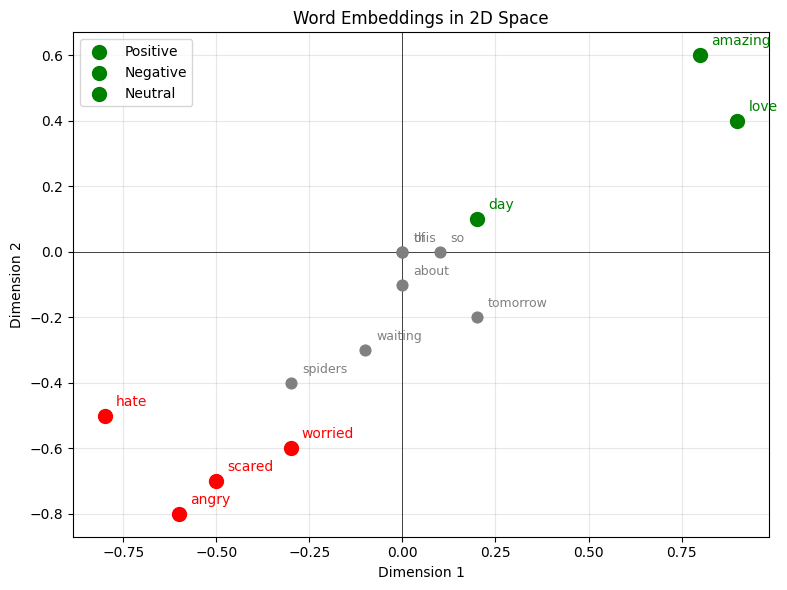

In [42]:
import matplotlib.pyplot as plt

# Categorize words by sentiment
positive_words = ["amazing", "day", "love"]
negative_words = ["scared", "angry", "worried", "hate"]
neutral_words = ["of", "this", "so", "about", "tomorrow", "spiders", "waiting"]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for word in positive_words:
    e = embeddings[word]
    ax.scatter(e[0], e[1], c='green', s=100, zorder=5)
    ax.annotate(word, (e[0]+0.03, e[1]+0.03), fontsize=10, color='green')

for word in negative_words:
    e = embeddings[word]
    ax.scatter(e[0], e[1], c='red', s=100, zorder=5)
    ax.annotate(word, (e[0]+0.03, e[1]+0.03), fontsize=10, color='red')

for word in neutral_words:
    e = embeddings[word]
    ax.scatter(e[0], e[1], c='gray', s=60, zorder=5)
    ax.annotate(word, (e[0]+0.03, e[1]+0.03), fontsize=9, color='gray')

ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Word Embeddings in 2D Space')
ax.legend(['Positive', 'Negative', 'Neutral'], loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis:**

1. **Positive words** (amazing, love, day) cluster in the **upper-right quadrant** with positive values in both dimensions.

2. **Negative words** (angry, hate, scared, worried) cluster in the **lower-left quadrant** with negative values in both dimensions.

3. **Neutral/function words** (of, this, so, about) cluster near the **origin** with small magnitudes, meaning they carry little sentiment signal.

4. **Semantic relationship advantage over bag-of-words:** In the embedding space, semantically similar words are geometrically close. For instance, "hate" and "angry" are near each other. In bag-of-words, every word is equidistant from every other word (orthogonal one-hot vectors), so the model cannot leverage word similarity at all. Embeddings give the MLP a much richer starting point.

---
## Problem 3: Linear Classifier Implementation

Now we move from theory to code. We implement a multiclass linear classifier for emotion detection in tweets using bag-of-words features, NumPy, and einops.

**Architecture:** $\text{text} \to \text{bag-of-words vector} \to W^T f(x) + b \to \text{softmax} \to \text{class probabilities}$

In [1]:
# vocabulary class (from util.py in the lecture code)
class Vocabulary:
    """Maps strings to integers."""
    def __init__(self):
        self.index_to_string: list[str] = []
        self.string_to_index: dict[str, int] = {}

    def get_index(self, string: str) -> int:
        index = self.string_to_index.get(string)
        if index is None:
            index = len(self.index_to_string)
            self.index_to_string.append(string)
            self.string_to_index[string] = index
        return index

    def get_string(self, index: int) -> str:
        return self.index_to_string[index]

    def __len__(self):
        return len(self.index_to_string)

### 3.1 build_vocabulary

Build a vocabulary from training examples. Each example is a `(text, label)` pair.

In [44]:
def build_vocabulary(examples):
    """Build a vocabulary from training examples.
    
    Args:
        examples: list of (text, label) tuples
    Returns:
        vocab: Vocabulary object with all words from training texts
    """
    vocab = Vocabulary()
    for text, label in examples:
        for word in text.split():
            vocab.get_index(word)  # adds word if not already present
    return vocab

# Test
test_examples = [
    ("amazing day", "Joy"),
    ("scared of spiders", "Fear"),
    ("love this", "Joy"),
    ("so angry", "Anger"),
]
test_vocab = build_vocabulary(test_examples)
print(f"Vocabulary size: {len(test_vocab)}")
print(f"Words: {test_vocab.index_to_string}")

Vocabulary size: 9
Words: ['amazing', 'day', 'scared', 'of', 'spiders', 'love', 'this', 'so', 'angry']


### 3.2 text_to_features

Convert a text string to a sparse bag-of-words feature vector.

In [45]:
def text_to_features(text, vocab):
    """Convert text to a bag-of-words feature vector.
    
    Args:
        text: input string
        vocab: Vocabulary object
    Returns:
        features: numpy array of shape (vocab_size,) with word counts
    """
    features = np.zeros(len(vocab))
    for word in text.split():
        index = vocab.string_to_index.get(word)
        if index is not None:  # only count words in vocabulary
            features[index] += 1
    return features

# Test
f = text_to_features("so so angry", test_vocab)
print(f"Features for 'so so angry': {f}")
for i, count in enumerate(f):
    if count > 0:
        print(f"  {test_vocab.get_string(i)}: {int(count)}")

Features for 'so so angry': [0. 0. 0. 0. 0. 0. 0. 2. 1.]
  so: 2
  angry: 1


### 3.3 numpy_softmax

Implement softmax using NumPy and einops. Must handle batched inputs.

From Lecture 3: $p_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$

**Numerical stability trick:** Subtract the max logit before exponentiating to avoid overflow.

In [46]:
def numpy_softmax(logits):
    """Compute softmax probabilities from logits.
    
    Args:
        logits: numpy array of shape (batch_size, num_classes)
    Returns:
        probs: numpy array of same shape, each row sums to 1
    """
    # Subtract max for numerical stability (doesn't change the result)
    shifted = logits - reduce(logits, 'b c -> b 1', 'max')
    exp_logits = np.exp(shifted)
    normalizer = reduce(exp_logits, 'b c -> b 1', 'sum')
    return exp_logits / normalizer

# Test
test_logits = np.array([[2.0, 1.0, -1.0], [0.0, 0.0, 0.0]])
probs = numpy_softmax(test_logits)
print(f"Logits:\n{test_logits}")
print(f"Softmax:\n{probs}")
print(f"Row sums: {probs.sum(axis=1)}")
print(f"\nEqual logits -> uniform distribution: {np.allclose(probs[1], [1/3, 1/3, 1/3])}")

Logits:
[[ 2.  1. -1.]
 [ 0.  0.  0.]]
Softmax:
[[0.70538451 0.25949646 0.03511903]
 [0.33333333 0.33333333 0.33333333]]
Row sums: [1. 1.]

Equal logits -> uniform distribution: True


### 3.4 numpy_cross_entropy_loss

Compute the average cross-entropy loss over a batch.

In [47]:
def numpy_cross_entropy_loss(predictions, targets, epsilon=1e-10):
    """Compute average cross-entropy loss.
    
    Args:
        predictions: numpy array of shape (batch_size, num_classes) -- softmax probabilities
        targets: numpy array of shape (batch_size,) -- integer class labels
        epsilon: small constant to avoid log(0)
    Returns:
        loss: scalar float, averaged over the batch
    """
    batch_size = predictions.shape[0]
    # Clip predictions to avoid log(0)
    clipped = np.clip(predictions, epsilon, 1 - epsilon)
    # Select the predicted probability of the true class for each example
    correct_probs = clipped[np.arange(batch_size), targets]
    # Average negative log probability
    loss = -np.mean(np.log(correct_probs))
    return float(loss)

# Test
test_preds = np.array([[0.7, 0.2, 0.1], [0.1, 0.8, 0.1]])
test_targets = np.array([0, 1])  # first example is class 0, second is class 1
loss = numpy_cross_entropy_loss(test_preds, test_targets)
print(f"Predictions: {test_preds}")
print(f"Targets: {test_targets}")
print(f"Loss: {loss:.4f}")
print(f"Expected: mean(-log(0.7), -log(0.8)) = {(-np.log(0.7) + -np.log(0.8))/2:.4f}")

Predictions: [[0.7 0.2 0.1]
 [0.1 0.8 0.1]]
Targets: [0 1]
Loss: 0.2899
Expected: mean(-log(0.7), -log(0.8)) = 0.2899


### 3.5 numpy_compute_gradients

Compute gradients of cross-entropy loss w.r.t. weights and bias.

From Problem 1d, we showed that $\frac{\partial L}{\partial z_k} = p_k - y_k$.

Since $z = W^T f(x) + b$, by the chain rule:
- $\frac{\partial L}{\partial W} = f(x) \cdot (p - y)^T$
- $\frac{\partial L}{\partial b} = p - y$

In [48]:
def numpy_compute_gradients(features, predictions, targets):
    """Compute gradients of cross-entropy loss w.r.t. weights and bias.
    
    Args:
        features: numpy array of shape (batch_size, vocab_size)
        predictions: numpy array of shape (batch_size, num_classes) -- softmax probs
        targets: numpy array of shape (batch_size,) -- integer class labels
    Returns:
        grad_weights: numpy array of shape (vocab_size, num_classes)
        grad_bias: numpy array of shape (num_classes,)
    """
    batch_size = features.shape[0]
    num_classes = predictions.shape[1]
    
    # Convert targets to one-hot: shape (batch_size, num_classes)
    one_hot_targets = np.zeros((batch_size, num_classes))
    one_hot_targets[np.arange(batch_size), targets] = 1
    
    # dL/dz = predictions - one_hot_targets, shape (batch_size, num_classes)
    dz = predictions - one_hot_targets
    
    # dL/dW = features^T @ dz / batch_size, shape (vocab_size, num_classes)
    grad_weights = features.T @ dz / batch_size
    
    # dL/db = mean of dz over batch, shape (num_classes,)
    grad_bias = np.mean(dz, axis=0)
    
    return grad_weights, grad_bias

# Quick test
test_feats = np.array([[1.0, 0.0, 1.0], [0.0, 1.0, 1.0]])  # 2 examples, 3 features
test_preds = np.array([[0.7, 0.2, 0.1], [0.1, 0.1, 0.8]])  # 2 examples, 3 classes
test_targs = np.array([0, 2])
gw, gb = numpy_compute_gradients(test_feats, test_preds, test_targs)
print(f"Weight gradients shape: {gw.shape}")
print(f"Bias gradients shape: {gb.shape}")

Weight gradients shape: (3, 3)
Bias gradients shape: (3,)


### 3.6 predict_linear_classifier

Run the full forward pass: features -> logits -> softmax -> argmax prediction -> accuracy.

In [49]:
def predict_linear_classifier(features, labels, weights, bias):
    """Predict using a linear classifier and compute accuracy.
    
    Args:
        features: numpy array of shape (num_examples, vocab_size)
        labels: numpy array of shape (num_examples,) -- integer class labels
        weights: numpy array of shape (vocab_size, num_classes)
        bias: numpy array of shape (num_classes,)
    Returns:
        predictions: numpy array of shape (num_examples,) -- predicted class indices
        accuracy: float
    """
    # Forward pass
    logits = features @ weights + bias  # (num_examples, num_classes)
    probs = numpy_softmax(logits)
    predictions = np.argmax(probs, axis=1)
    accuracy = np.mean(predictions == labels)
    return predictions, float(accuracy)

### 3.7 train_linear_classifier

Complete training loop using gradient descent.

**From Lecture 3 (Sections 12-13):** The training pipeline:
1. Forward pass: compute logits, softmax, loss
2. Backward pass: compute gradients
3. Update: adjust weights in the direction that reduces loss

In [50]:
def train_linear_classifier(train_texts, train_labels, val_texts, val_labels,
                            num_classes=3, num_epochs=50, learning_rate=0.01):
    """Train a linear classifier from scratch.
    
    Args:
        train_texts: list of strings (training)
        train_labels: list of int labels (training)
        val_texts: list of strings (validation -- only for evaluation)
        val_labels: list of int labels (validation)
        num_classes: number of output classes
        num_epochs: number of training epochs
        learning_rate: step size for gradient descent
    Returns:
        weights, bias, vocab, train_losses, val_accuracies
    """
    # Build vocabulary from training data only
    train_examples = list(zip(train_texts, train_labels))
    vocab = build_vocabulary(train_examples)
    vocab_size = len(vocab)
    
    # Convert texts to feature matrices
    train_features = np.array([text_to_features(t, vocab) for t in train_texts])
    val_features = np.array([text_to_features(t, vocab) for t in val_texts])
    train_labels = np.array(train_labels)
    val_labels = np.array(val_labels)
    
    # Initialize parameters
    np.random.seed(42)
    weights = np.random.randn(vocab_size, num_classes) * 0.01  # small random
    bias = np.zeros(num_classes)
    
    train_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        # Forward pass on training data
        logits = train_features @ weights + bias
        predictions = numpy_softmax(logits)
        loss = numpy_cross_entropy_loss(predictions, train_labels)
        
        # Compute gradients
        grad_w, grad_b = numpy_compute_gradients(train_features, predictions, train_labels)
        
        # Update parameters (gradient descent)
        weights -= learning_rate * grad_w
        bias -= learning_rate * grad_b
        
        # Evaluate on validation set
        _, val_acc = predict_linear_classifier(val_features, val_labels, weights, bias)
        
        train_losses.append(loss)
        val_accuracies.append(val_acc)
        
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch:3d} | Train Loss: {loss:.4f} | Val Accuracy: {val_acc:.4f}")
    
    return weights, bias, vocab, train_losses, val_accuracies

### Test on the toy dataset

In [51]:
# Toy dataset from the homework
train_texts = [
    "amazing day",
    "scared of spiders",
    "love this",
    "so angry",
    "so so worried about tomorrow",
    "hate waiting",
]
train_labels = [0, 2, 0, 1, 2, 1]  # Joy=0, Anger=1, Fear=2

# Use same data as validation for this toy test
val_texts = train_texts
val_labels = train_labels

weights, bias, vocab, losses, accs = train_linear_classifier(
    train_texts, train_labels, val_texts, val_labels,
    num_classes=3, num_epochs=100, learning_rate=0.1
)

Epoch   0 | Train Loss: 1.1052 | Val Accuracy: 1.0000
Epoch  10 | Train Loss: 0.8587 | Val Accuracy: 1.0000
Epoch  20 | Train Loss: 0.6904 | Val Accuracy: 1.0000
Epoch  30 | Train Loss: 0.5684 | Val Accuracy: 1.0000
Epoch  40 | Train Loss: 0.4771 | Val Accuracy: 1.0000
Epoch  50 | Train Loss: 0.4072 | Val Accuracy: 1.0000
Epoch  60 | Train Loss: 0.3528 | Val Accuracy: 1.0000
Epoch  70 | Train Loss: 0.3097 | Val Accuracy: 1.0000
Epoch  80 | Train Loss: 0.2749 | Val Accuracy: 1.0000
Epoch  90 | Train Loss: 0.2464 | Val Accuracy: 1.0000
Epoch  99 | Train Loss: 0.2250 | Val Accuracy: 1.0000


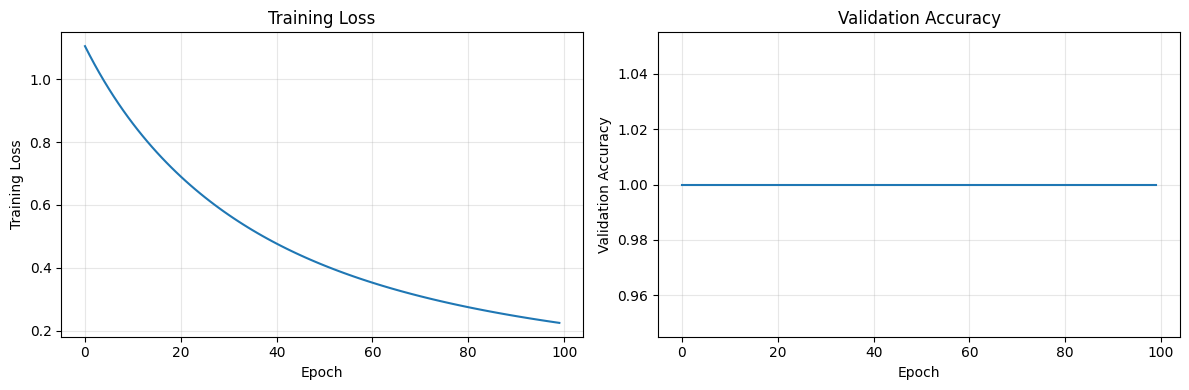

In [52]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(accs)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Validation Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.8 & 3.9 Learning Rate Experiments

Experiment with three different learning rates to observe the effect on training.


Learning rate = 0.001
Epoch   0 | Train Loss: 1.1052 | Val Accuracy: 0.3333
Epoch  10 | Train Loss: 1.1022 | Val Accuracy: 0.3333
Epoch  20 | Train Loss: 1.0992 | Val Accuracy: 0.3333
Epoch  30 | Train Loss: 1.0962 | Val Accuracy: 0.3333
Epoch  40 | Train Loss: 1.0933 | Val Accuracy: 0.3333
Epoch  50 | Train Loss: 1.0903 | Val Accuracy: 0.5000
Epoch  60 | Train Loss: 1.0874 | Val Accuracy: 0.5000
Epoch  70 | Train Loss: 1.0845 | Val Accuracy: 0.5000
Epoch  80 | Train Loss: 1.0816 | Val Accuracy: 0.6667
Epoch  90 | Train Loss: 1.0787 | Val Accuracy: 0.6667
Epoch  99 | Train Loss: 1.0761 | Val Accuracy: 1.0000

Learning rate = 0.1
Epoch   0 | Train Loss: 1.1052 | Val Accuracy: 1.0000
Epoch  10 | Train Loss: 0.8587 | Val Accuracy: 1.0000
Epoch  20 | Train Loss: 0.6904 | Val Accuracy: 1.0000
Epoch  30 | Train Loss: 0.5684 | Val Accuracy: 1.0000
Epoch  40 | Train Loss: 0.4771 | Val Accuracy: 1.0000
Epoch  50 | Train Loss: 0.4072 | Val Accuracy: 1.0000
Epoch  60 | Train Loss: 0.3528 | Val A

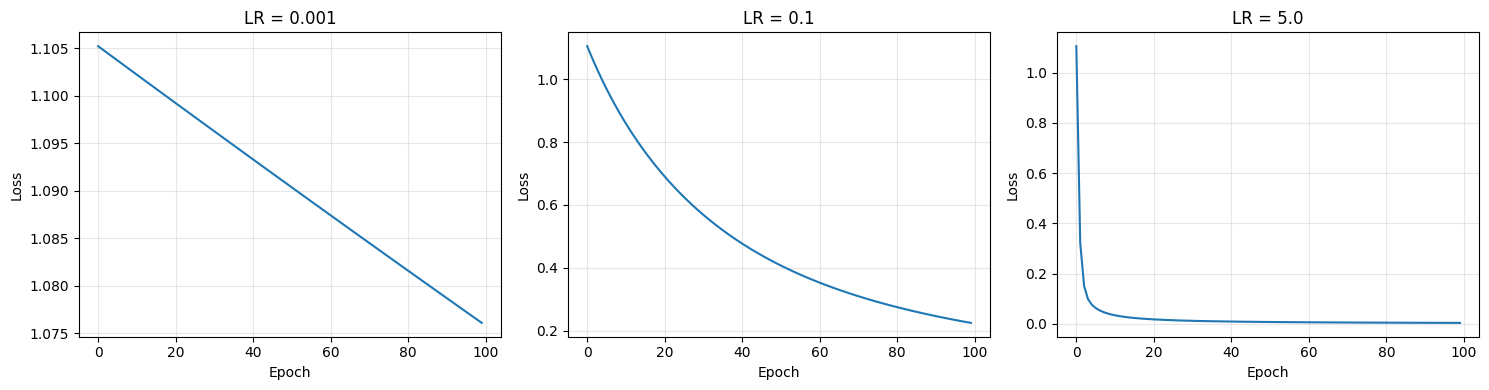

In [53]:
learning_rates = [0.001, 0.1, 5.0]
lr_results = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, lr in enumerate(learning_rates):
    print(f"\n{'='*40}")
    print(f"Learning rate = {lr}")
    print(f"{'='*40}")
    w, b, v, losses, accs = train_linear_classifier(
        train_texts, train_labels, val_texts, val_labels,
        num_classes=3, num_epochs=100, learning_rate=lr
    )
    lr_results[lr] = (losses, accs)
    
    axes[i].plot(losses, label='Train Loss')
    axes[i].set_title(f'LR = {lr}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Learning rate analysis:**

| Learning Rate | Behavior |
|:---:|:---|
| **0.001** (too small) | Loss decreases very slowly. The model barely learns within 100 epochs because each gradient step is tiny. |
| **0.1** (good) | Loss decreases steadily and converges. This is a well-tuned learning rate for this problem. |
| **5.0** (too large) | Loss oscillates wildly or diverges. Steps overshoot the minimum, bouncing back and forth. |

**Why learning rate matters:** The learning rate controls the step size in gradient descent. From Lecture 3:
- Too small: optimization converges, but painfully slowly. You may not reach a good solution in a reasonable number of epochs.
- Too large: optimization overshoots the loss minimum. In extreme cases, the loss can increase and the model diverges.
- Just right: the loss decreases efficiently and the model converges to a good solution.

---
## Problem 4: MLP with Embeddings

Now we upgrade from bag-of-words + linear classifier to averaged embeddings + MLP.

**Architecture (from Lecture 4, Section 5):**

$$\text{text} \to \text{average embedding} \xrightarrow{W_1, b_1} \text{ReLU} \xrightarrow{W_2, b_2} \text{logits} \to \text{softmax} \to \text{class probs}$$

Key difference from Problem 3: embeddings are **learned** -- they start random and are updated during training.

### 4.1 text_to_average_embedding

In [54]:
def text_to_average_embedding(text, vocab, embedding_layer):
    """Convert text to an averaged embedding vector.
    
    Args:
        text: input string
        vocab: Vocabulary object
        embedding_layer: nn.Embedding
    Returns:
        averaged embedding tensor of shape (embedding_dim,)
    """
    words = text.split()
    # Get vocabulary indices for each word (skip unknown words)
    indices = []
    for word in words:
        idx = vocab.string_to_index.get(word)
        if idx is not None:
            indices.append(idx)
    
    if len(indices) == 0:
        # No known words -- return zero vector
        return torch.zeros(embedding_layer.embedding_dim)
    
    # Convert to tensor and look up embeddings
    index_tensor = torch.tensor(indices, dtype=torch.long)
    word_embeddings = embedding_layer(index_tensor)  # shape: (num_words, embedding_dim)
    
    # Average across the word dimension using einops
    averaged = reduce(word_embeddings, 'words dim -> dim', 'mean')
    return averaged

# Test
test_vocab = build_vocabulary([("hello world test", 0)])
test_embed = nn.Embedding(len(test_vocab), 4)  # 3 words, 4-dim embeddings
avg = text_to_average_embedding("hello world", test_vocab, test_embed)
print(f"Averaged embedding shape: {avg.shape}")
print(f"Averaged embedding: {avg}")

Averaged embedding shape: torch.Size([4])
Averaged embedding: tensor([ 1.5469,  0.5501,  0.5169, -0.8275], grad_fn=<MeanBackward1>)


### 4.2 extract_averaged_features

In [55]:
def extract_averaged_features(texts, vocab, embedding_layer):
    """Extract averaged embedding features for a batch of texts.
    
    Args:
        texts: list of strings
        vocab: Vocabulary object
        embedding_layer: nn.Embedding
    Returns:
        tensor of shape (num_texts, embedding_dim)
    """
    embeddings_list = []
    for text in texts:
        avg_emb = text_to_average_embedding(text, vocab, embedding_layer)
        embeddings_list.append(avg_emb)
    return torch.stack(embeddings_list)

# Test
feats = extract_averaged_features(["hello world", "test"], test_vocab, test_embed)
print(f"Features shape: {feats.shape}  (2 texts, 4-dim embeddings)")

Features shape: torch.Size([2, 4])  (2 texts, 4-dim embeddings)


### 4.3 MLPClassifier

A simple MLP: linear -> ReLU -> linear (outputs raw logits).

This is exactly the architecture from Lecture 4, Section 12:

$$h = \text{ReLU}(W_1 x + b_1)$$
$$\text{logits} = W_2 h + b_2$$

In [56]:
class MLPClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, num_classes):
        super().__init__()
        self.w1 = nn.Linear(embedding_dim, hidden_dim)
        self.w2 = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        """Forward pass.
        
        Args:
            x: tensor of shape (batch_size, embedding_dim)
        Returns:
            logits: tensor of shape (batch_size, num_classes)
        """
        hidden = torch.relu(self.w1(x))  # (batch_size, hidden_dim)
        logits = self.w2(hidden)          # (batch_size, num_classes)
        return logits

# Test
mlp = MLPClassifier(embedding_dim=4, hidden_dim=8, num_classes=3)
dummy_input = torch.randn(2, 4)
output = mlp(dummy_input)
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output (logits): {output}")

Input shape: torch.Size([2, 4])
Output shape: torch.Size([2, 3])
Output (logits): tensor([[ 0.0649, -0.2329,  0.2794],
        [ 0.1536,  0.0345,  0.7996]], grad_fn=<AddmmBackward0>)


### 4.4 Utility Functions (PyTorch versions)

In [57]:
def torch_softmax(logits):
    """Convert logits to probabilities using softmax.
    
    Args:
        logits: tensor of shape (batch_size, num_classes)
    Returns:
        probs: tensor of same shape
    """
    shifted = logits - reduce(logits, 'b c -> b 1', 'max')
    exp_logits = torch.exp(shifted)
    normalizer = reduce(exp_logits, 'b c -> b 1', 'sum')
    return exp_logits / normalizer


def torch_cross_entropy_loss(predictions, targets):
    """Compute average cross-entropy loss.
    
    Args:
        predictions: tensor of shape (batch_size, num_classes) -- softmax probs
        targets: tensor of shape (batch_size,) -- integer class labels (long)
    Returns:
        loss: scalar tensor
    """
    batch_size = predictions.shape[0]
    clipped = torch.clamp(predictions, min=1e-10, max=1 - 1e-10)
    correct_probs = clipped[torch.arange(batch_size), targets]
    loss = -torch.mean(torch.log(correct_probs))
    return loss


def update_parameter(param, grad, lr):
    """Manual gradient descent step (no optimizer).
    
    Args:
        param: nn.Parameter to update
        grad: gradient tensor
        lr: learning rate
    """
    with torch.no_grad():
        param -= lr * grad

# Test softmax
test_logits = torch.tensor([[2.0, 1.0, -1.0]])
probs = torch_softmax(test_logits)
print(f"Softmax test: {probs} (sum = {probs.sum():.4f})")

# Test cross-entropy
test_preds = torch.tensor([[0.7, 0.2, 0.1]])
test_targets = torch.tensor([0])
loss = torch_cross_entropy_loss(test_preds, test_targets)
print(f"CE loss test: {loss:.4f} (expected: {-np.log(0.7):.4f})")

Softmax test: tensor([[0.7054, 0.2595, 0.0351]]) (sum = 1.0000)
CE loss test: 0.3567 (expected: 0.3567)


### 4.5 predict_mlp

In [58]:
def predict_mlp(texts, labels, classifier, embedding_layer, vocab):
    """Run MLP prediction and compute accuracy.
    
    Args:
        texts: list of strings
        labels: list of int labels
        classifier: MLPClassifier
        embedding_layer: nn.Embedding
        vocab: Vocabulary
    Returns:
        accuracy: float
    """
    # Set to evaluation mode (disables dropout etc. if present)
    classifier.eval()
    embedding_layer.eval()
    
    with torch.no_grad():
        features = extract_averaged_features(texts, vocab, embedding_layer)
        logits = classifier(features)
        probs = torch_softmax(logits)
        predictions = torch.argmax(probs, dim=1)
        labels_tensor = torch.tensor(labels, dtype=torch.long)
        accuracy = (predictions == labels_tensor).float().mean().item()
    
    return accuracy

### 4.6 train_mlp_classifier

Complete training loop with manual SGD (no PyTorch optimizers).

**From Lecture 4:** Training loop = forward pass -> loss -> backward pass -> parameter update.

Key differences from the linear classifier:
1. Embeddings are learned (updated during training)
2. The model has nonlinear hidden layers (ReLU)
3. We use SGD with batches and shuffle each epoch

In [59]:
def train_mlp_classifier(train_texts, train_labels, val_texts, val_labels,
                         num_classes=3, embedding_dim=16, hidden_dim=32,
                         num_epochs=50, learning_rate=0.01, batch_size=8):
    """Train an MLP classifier with learned embeddings.
    
    Args:
        train_texts, train_labels: training data
        val_texts, val_labels: validation data (evaluation only)
        num_classes: number of output classes
        embedding_dim: dimension of word embeddings
        hidden_dim: dimension of MLP hidden layer
        num_epochs: number of training epochs
        learning_rate: step size for SGD
        batch_size: number of examples per mini-batch
    Returns:
        classifier, embedding_layer, vocab, train_losses, val_accuracies
    """
    # Build vocabulary from training data
    train_examples = list(zip(train_texts, train_labels))
    vocab = build_vocabulary(train_examples)
    vocab_size = len(vocab)
    
    # Initialize embedding layer and MLP
    torch.manual_seed(42)
    embedding_layer = nn.Embedding(vocab_size, embedding_dim)
    classifier = MLPClassifier(embedding_dim, hidden_dim, num_classes)
    
    train_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        classifier.train()
        embedding_layer.train()
        
        # Shuffle training data at each epoch
        indices = list(range(len(train_texts)))
        random.shuffle(indices)
        shuffled_texts = [train_texts[i] for i in indices]
        shuffled_labels = [train_labels[i] for i in indices]
        
        epoch_losses = []
        
        # Process in batches
        for start in range(0, len(shuffled_texts), batch_size):
            end = min(start + batch_size, len(shuffled_texts))
            batch_texts = shuffled_texts[start:end]
            batch_labels = torch.tensor(shuffled_labels[start:end], dtype=torch.long)
            
            # Forward pass
            features = extract_averaged_features(batch_texts, vocab, embedding_layer)
            logits = classifier(features)
            probs = torch_softmax(logits)
            loss = torch_cross_entropy_loss(probs, batch_labels)
            
            epoch_losses.append(loss.item())
            
            # Backward pass
            # Zero gradients manually
            for param in classifier.parameters():
                if param.grad is not None:
                    param.grad.zero_()
            if embedding_layer.weight.grad is not None:
                embedding_layer.weight.grad.zero_()
            
            loss.backward()
            
            # Manual SGD updates (no optimizer)
            for param in classifier.parameters():
                if param.grad is not None:
                    update_parameter(param, param.grad, learning_rate)
            if embedding_layer.weight.grad is not None:
                update_parameter(embedding_layer.weight, embedding_layer.weight.grad, learning_rate)
        
        avg_loss = np.mean(epoch_losses)
        train_losses.append(avg_loss)
        
        # Evaluate on validation set
        val_acc = predict_mlp(val_texts, val_labels, classifier, embedding_layer, vocab)
        val_accuracies.append(val_acc)
        
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch:3d} | Train Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.4f}")
    
    return classifier, embedding_layer, vocab, train_losses, val_accuracies

### Test MLP on the toy dataset

In [60]:
classifier, embed_layer, vocab, mlp_losses, mlp_accs = train_mlp_classifier(
    train_texts, train_labels, train_texts, train_labels,
    num_classes=3, embedding_dim=8, hidden_dim=16,
    num_epochs=100, learning_rate=0.05, batch_size=4
)

Epoch   0 | Train Loss: 1.0960 | Val Accuracy: 0.3333
Epoch  10 | Train Loss: 0.9942 | Val Accuracy: 0.5000
Epoch  20 | Train Loss: 0.8809 | Val Accuracy: 0.6667
Epoch  30 | Train Loss: 0.7618 | Val Accuracy: 0.8333
Epoch  40 | Train Loss: 0.5786 | Val Accuracy: 1.0000
Epoch  50 | Train Loss: 0.4843 | Val Accuracy: 1.0000
Epoch  60 | Train Loss: 0.4255 | Val Accuracy: 1.0000
Epoch  70 | Train Loss: 0.2896 | Val Accuracy: 1.0000
Epoch  80 | Train Loss: 0.2468 | Val Accuracy: 1.0000
Epoch  90 | Train Loss: 0.1806 | Val Accuracy: 1.0000
Epoch  99 | Train Loss: 0.1676 | Val Accuracy: 1.0000


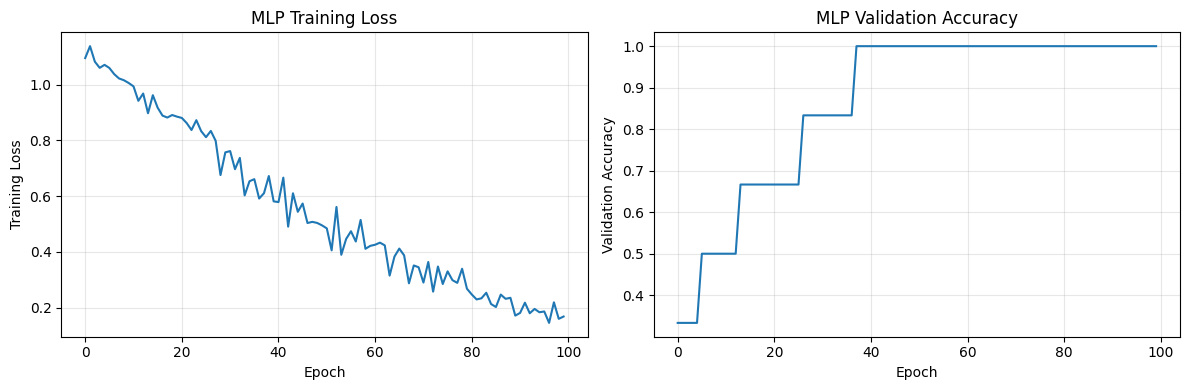

In [61]:
# Plot MLP training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(mlp_losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('MLP Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(mlp_accs)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('MLP Validation Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Compare Linear vs MLP

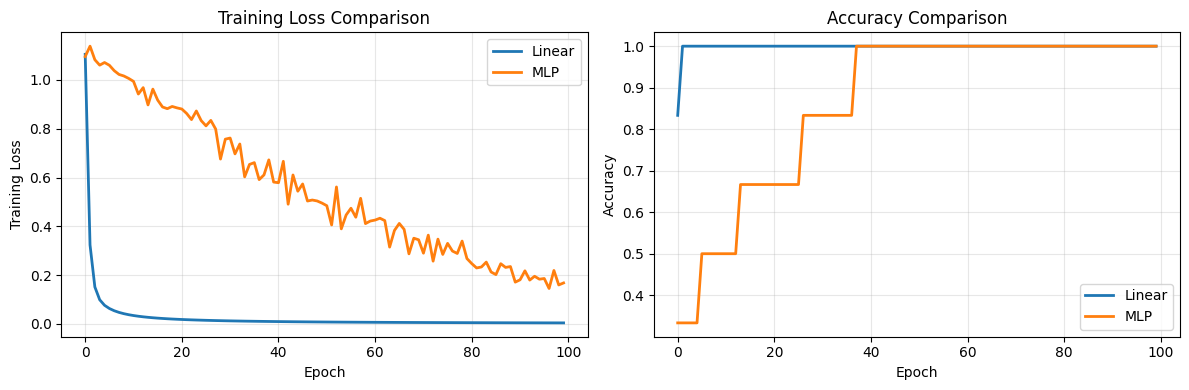

Final Linear accuracy: 1.0000
Final MLP accuracy:    1.0000


In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses, label='Linear', linewidth=2)
ax1.plot(mlp_losses, label='MLP', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(accs, label='Linear', linewidth=2)
ax2.plot(mlp_accs, label='MLP', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Linear accuracy: {accs[-1]:.4f}")
print(f"Final MLP accuracy:    {mlp_accs[-1]:.4f}")

---
## Key Takeaways

### From Lecture 3 (applied in Problems 1 & 3)
- **Bag-of-words** gives a simple, fixed-size text representation but loses word order
- **Softmax** converts logits to probabilities; **cross-entropy** measures how well those probabilities match the true labels
- The gradient $\nabla_z L = p - y$ is elegantly simple and provides smooth learning signals
- **Learning rate** is critical: too small = slow convergence, too large = divergence

### From Lecture 4 (applied in Problems 2 & 4)
- **Word embeddings** encode semantic similarity (unlike one-hot vectors)
- **ReLU** adds nonlinearity, allowing the MLP to learn curved decision boundaries
- **Backpropagation** computes gradients layer by layer using the chain rule
- The MLP learns both the feature representation (embeddings + hidden layer) and the classifier simultaneously
- More expressive models (MLP > linear) can achieve higher accuracy but require careful training (initialization, learning rate, etc.)